In [5]:
import numpy as np 
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
import random as rand

In [10]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    else:
        pass
    return n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs=0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss):
    if ss <= sw:
        fs=0
    else:
        fs = (((ss-sw)**beta1)*((1-ss)**beta22))/(((sopt-sw)**beta1)*((1-sopt)**beta22))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
#total conductance of the soil and diffusive barrier
def gt(ss):
    gt = ((n**2)*((1-ss)**(2+3/4.38))*(0.5**2)*0.756)/((n**2)*((1-ss)**(2+3/4.38)) +(0.5**2))
    return gt

# H2 Diffusive flux
def ff(ss,H):
    ff = gt(ss)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh):
    bd = hh*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh):
    vbd = Zr*bd(s, Cs, Bh)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh):
    hyd = Ha/(1 + (vbd(s, Cs, Bh)/gt(s)))
    return hyd


def rainfall(y):
    alpha_p = 1.5 # average precipitation per event[cm]
    rainfall_ = np.zeros(int(length/dt))
    for i in range(0, int(length/dt)):
        r = np.random.default_rng().exponential(y)
        if r < y*dt:
            rainfall_[i] = np.random.default_rng().exponential(alpha_p/(n*Zr))
        else:
            rainfall_[i] = 0
    return rainfall_

In [3]:
x = "loamy sand"
n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil(x)

In [7]:
length = 730 # simulation time (days)
s0 = 0.5 # Soil moisture at the beginnig of the simulation [-]
Ha = 530  #(*Atmospheric concentration of hydrogen* ppb)
dt = 0.001 # time interval (days)
s_ve = np.linspace(0,1,int(length/dt))
time = np.linspace(0,length-dt,int(length/dt)) # Time vector

y = 0.2 # Rainfall frequency
rain_vec = rainfall(y) # rainfall vec
plt.plot(time, rain_vec);

In [14]:
# Soil moisture drydown 
ss_dry = np.zeros(int(dry/dt))
ss_dry[0] = 1
def drydown(x):
    ss_vec = x.copy()
    for i in range(1, int(dry/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] - dt*loss
            
    return ss_vec
    
# Soil moisture Equation solution
def run_ss(x):
    ss_vec = x.copy()
    for i in range(1, int(length/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] + rain_vec[i] - dt*loss
            
    return ss_vec

In [5]:
ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 3.2*10**-4 # Potential decomposition rate for hydrogen
kcc = 1.8*10**-3 # Potential decomposition rate for carbon
mc = 0.005 # Mortality rate for carbon microbes
mh = 0.005 # Mortality rate for Hydrogen microbes
rc = 0.6 # Respiration rate for Carbon microbes
rh = 0.6 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H] 0.0072 converts Kh timescale to /day, and H to gH/m3

# Added plant litter
def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

# Solution to dC/dt Forward Euler
def substrate_sol(i):
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fh(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    DEC_h = q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc[i-1]
    BD_h = mh*Bh[i-1]
    cs = Cs[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

# Solution to dBC/dt CDB biomass
def Microbe_c(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    BD_c = mc*Bc[i-1]
    bc = Bc[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

# Solution to dBH/dt HOB biomass
def Microbe_h(i):
    kh = khh*hh*fh(ss[i-1])
    DEC_h = q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh[i-1]
    bh = Bh[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

# Solution to dH/dt Hydrogen
def run_hyd(i):
    flux = ff(ss[i-1], H[i-1])
    b_d = bd(ss[i-1], Cs[i-1], Bh[i-1])*H[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H[i-1] + ((flux - b_d))/(n*Zr*air) + H[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

# solution vectors
Cs = np.zeros(int(length/dt))
Cs[0] = 80
Bc = np.zeros(int(length/dt))
Bc[0] = 5
Bh = np.zeros(int(length/dt))
Bh[0] = 1
ss_vec = np.zeros(int(length/dt))
ss_vec[0] = s0

hyd_vec = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec[0] = hyd(s0, Cs[0], Bh[0])
H = np.zeros(int(length/dt))
H[0] = hyd_vec[0]

In [16]:
%%time
ss = run_ss(ss_vec) # Soil moisture solution
# Added litter
ADd = ADD(np.mean(ss))
# Loop for solution
for i in range(1, int(length/dt)):
    Bc[i] = Microbe_c(i)
    Cs[i] = substrate_sol(i)
    Bh[i] = Microbe_h(i)
    H[i] = run_hyd(i)
    hyd_vec[i] = hyd(ss[i], Cs[i], Bh[i])

CPU times: user 7.06 s, sys: 9.77 ms, total: 7.07 s
Wall time: 7.08 s


In [11]:
# Bertagni et al. 2021 formulation 
def run_hyd1(i):
    flux = ff(ss[i-1], c[i-1])
    b_d = 0.03*fh(ss[i-1])*hh*c[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = c[i-1] + ((flux - b_d)/(n*Zr*air)) + c[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

# Quasi steady approximation

def hyd1(s):
    hyd = Ha/(1 + ((0.03*fh(s)*hh*Zr)/gt(s)))
    return hyd

c = np.zeros(int(length/dt))
c1 = np.zeros(int(length/dt))
c1[0] = hyd1(s0)
c[0] = c1[0]

for i in range(1, int(length/dt)):
    c[i] = run_hyd1(i)
    c1[i] = hyd1(ss[i])

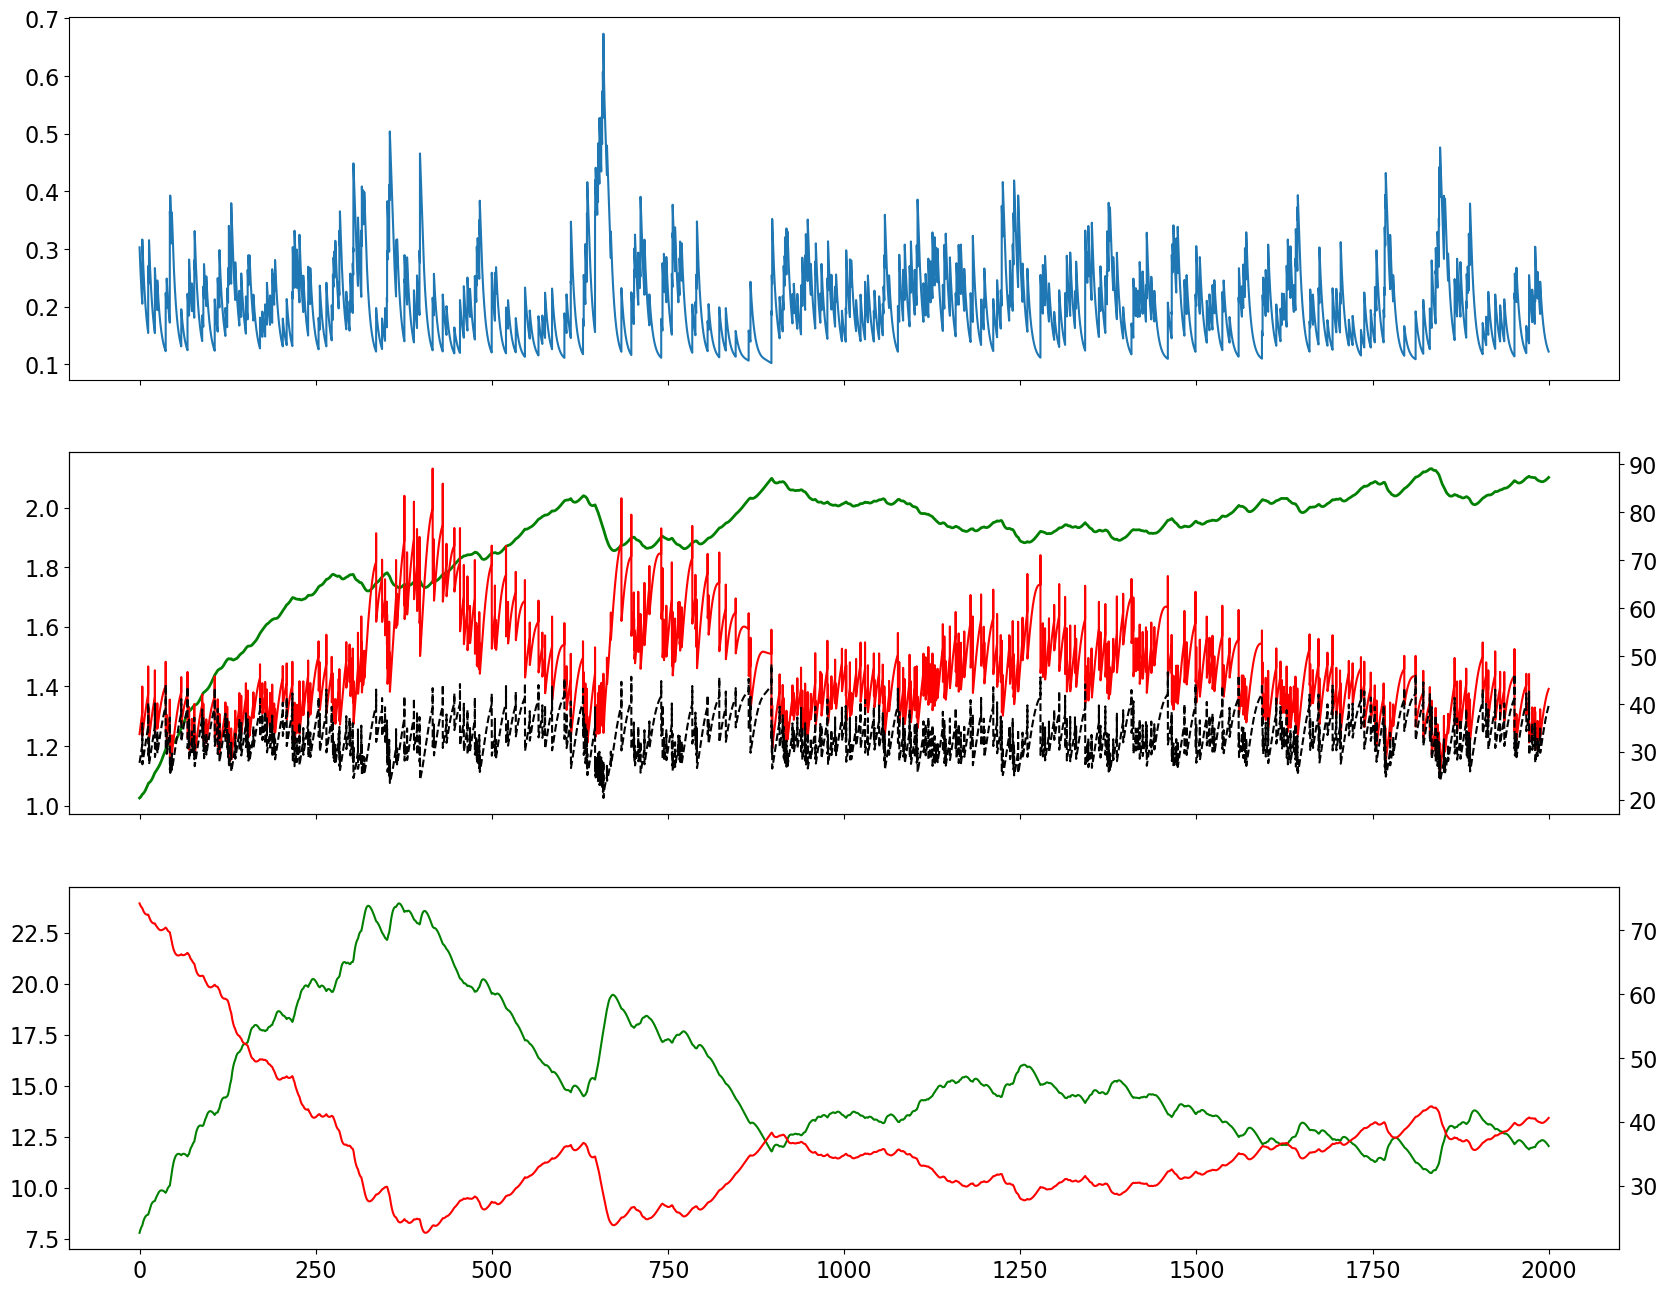

In [13]:
# Plots Figure 5 in paper
fig, axs = plt.subplots(3, 1, figsize=(20,16), sharex=True)
axs[0].plot(time[0:2000000], ss[20000:2020000])
axs[1].plot(time[0:2000000], Bh[20000:2020000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:2000000], H[20000:2020000], color="red")
ax2.plot(time[0:2000000], c[20000:2020000], color="black", linestyle="dashed")
axs[2].plot(time[0:2000000], Bc[20000:2020000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:2000000], Cs[20000:2020000], color="red")

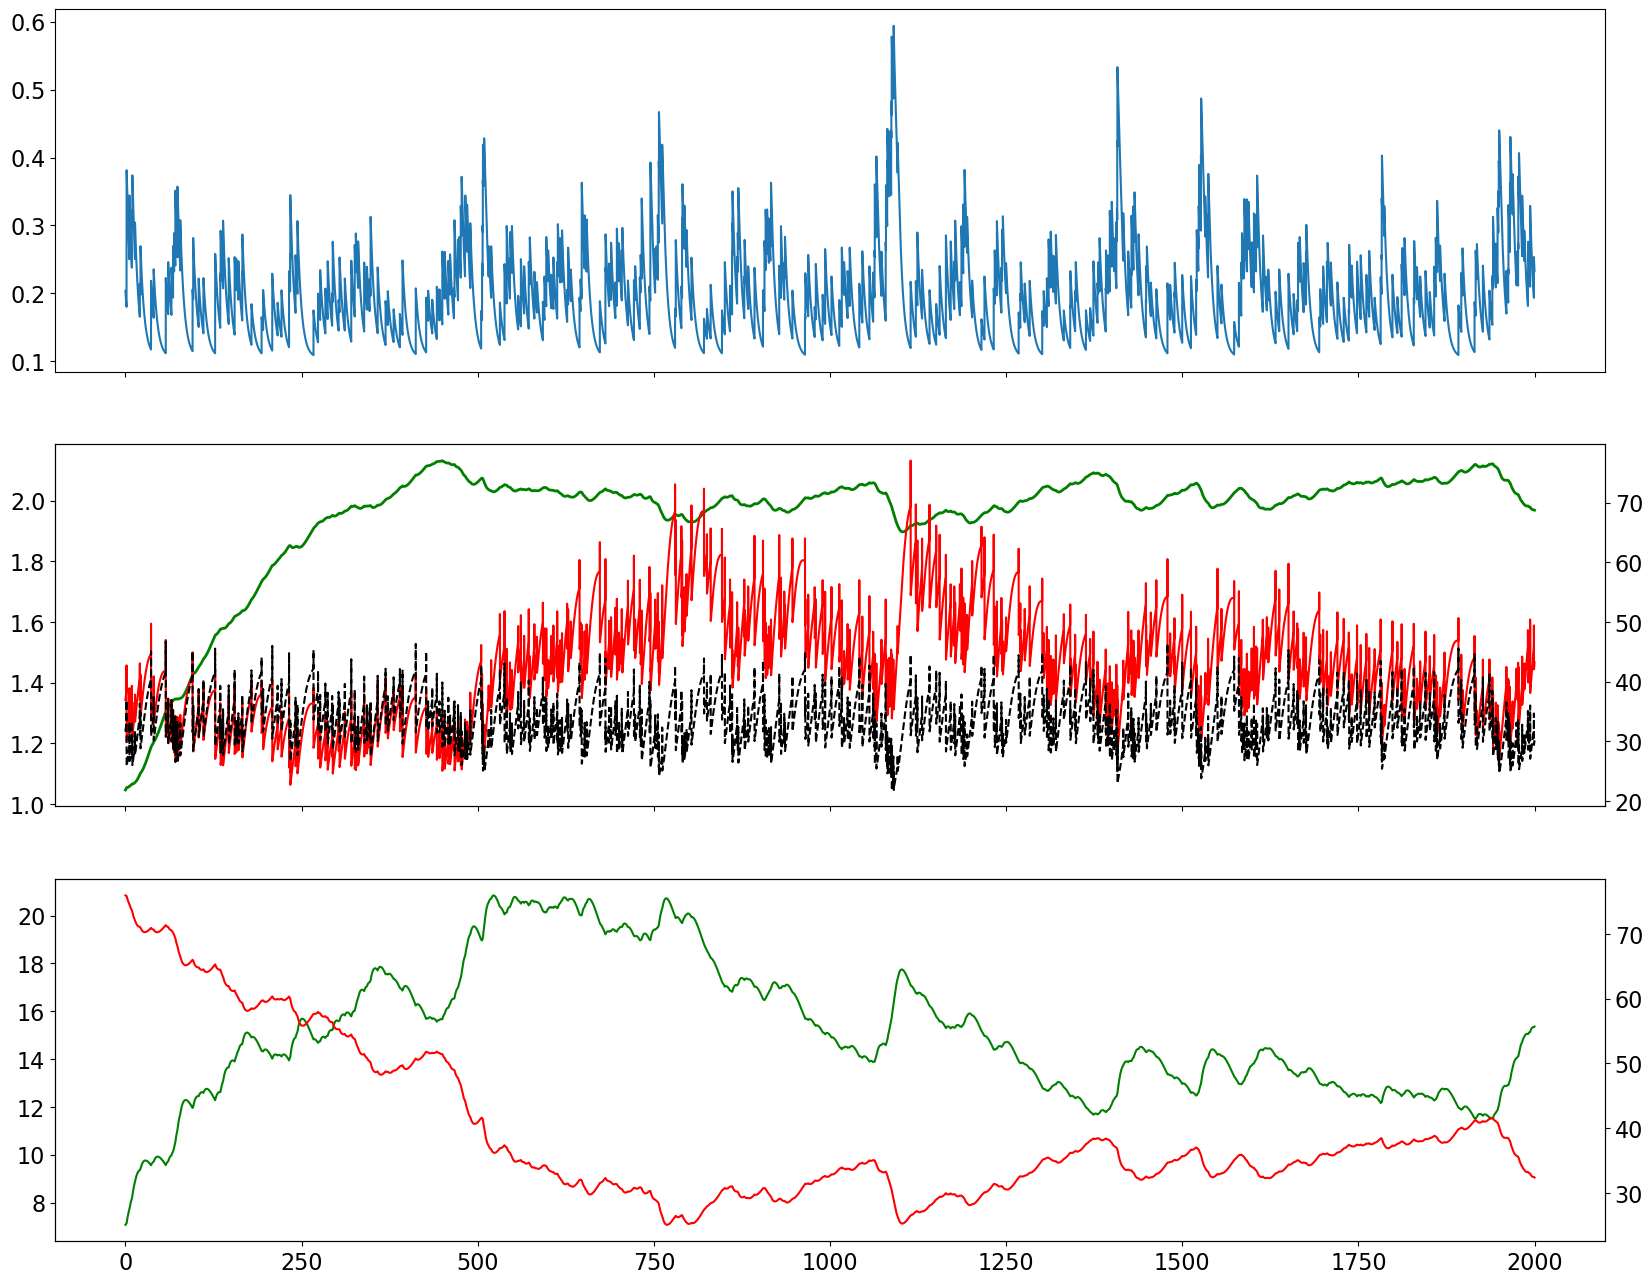

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(20,16), sharex=True)
axs[0].plot(time[0:2000000], ss[20000:2020000])
axs[1].plot(time[0:2000000], Bh[20000:2020000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:2000000], H[20000:2020000], color="red")
ax2.plot(time[0:2000000], c[20000:2020000], color="black", linestyle="dashed")
axs[2].plot(time[0:2000000], Bc[20000:2020000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:2000000], Cs[20000:2020000], color="red")

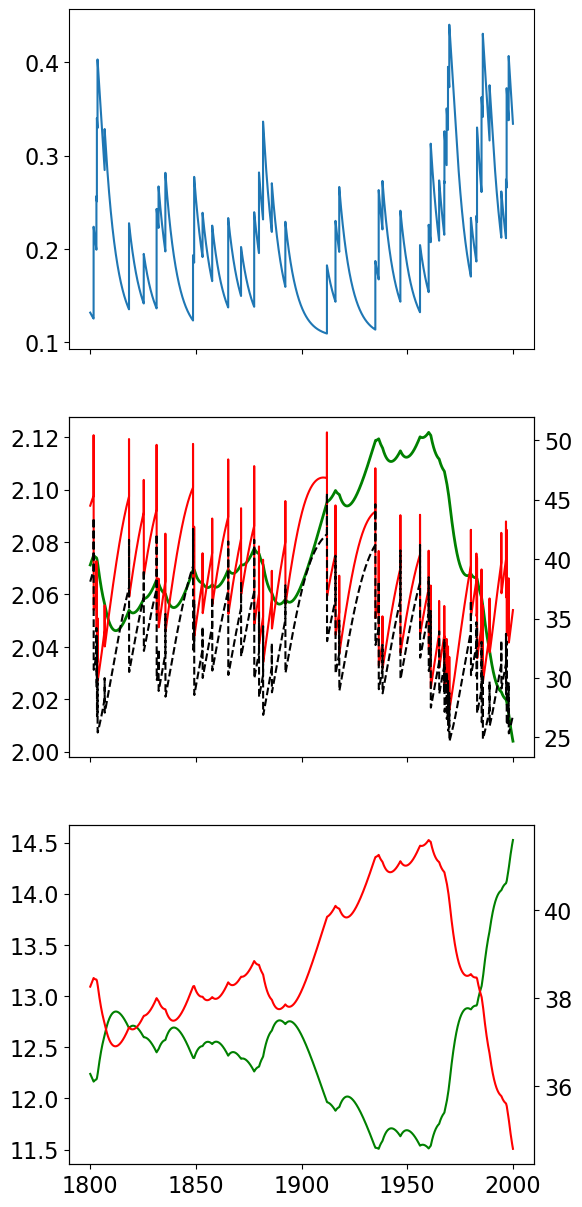

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(6,15), sharex=True)
axs[0].plot(time[1800000:2000000], ss[1800000:2000000])
axs[1].plot(time[1800000:2000000], Bh[1800000:2000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[1800000:2000000], H[1800000:2000000], color="red")
ax2.plot(time[1800000:2000000], c[1800000:2000000], color="black", linestyle="dashed")
axs[2].plot(time[1800000:2000000], Bc[1800000:2000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[1800000:2000000], Cs[1800000:2000000], color="red")

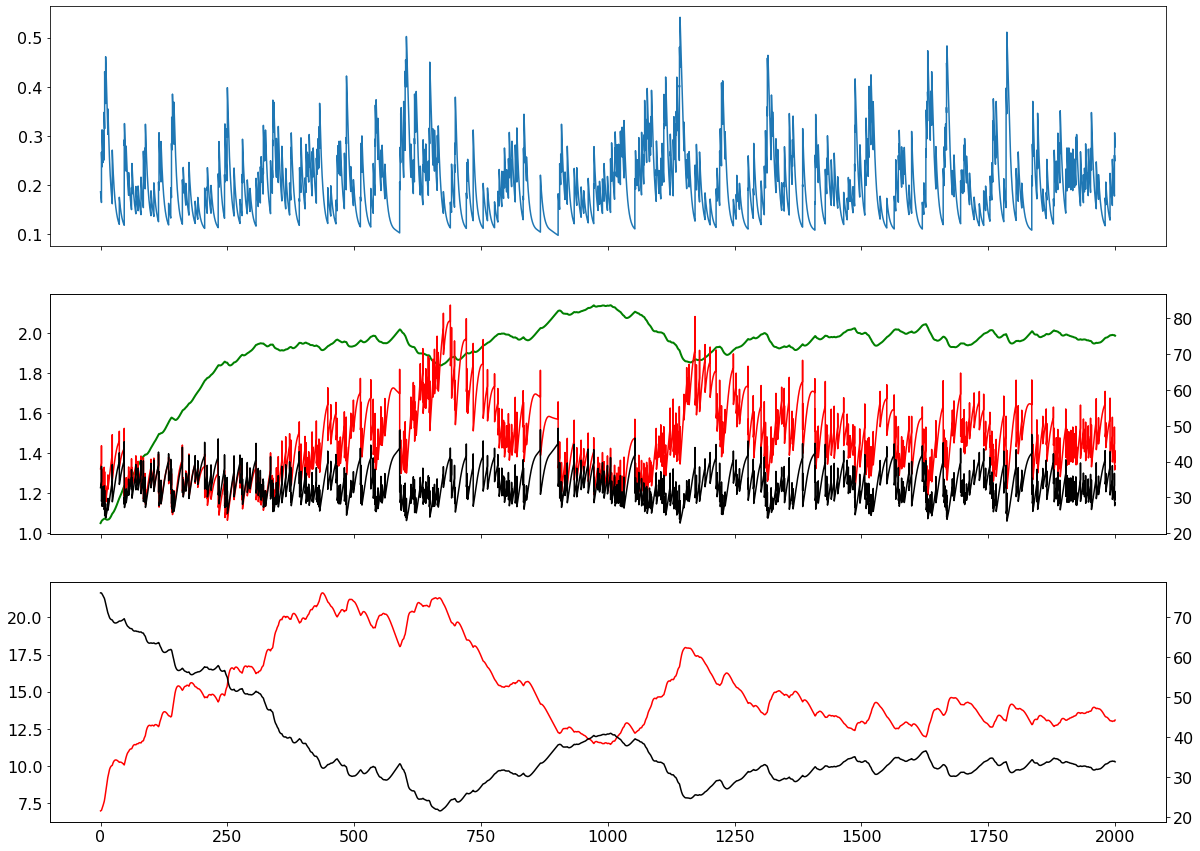

In [18]:
fig, axs = plt.subplots(3, 1, figsize=(20,15), sharex=True)
axs[0].plot(time[0:2000000], ss[20000:2020000])
axs[1].plot(time[0:2000000], Bh[20000:2020000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:2000000], H[20000:2020000], color="red")
ax2.plot(time[0:2000000], c[20000:2020000], color="black", linestyle="dashed")
axs[2].plot(time[0:2000000], Bc[20000:2020000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:2000000], Cs[20000:2020000], color="red")

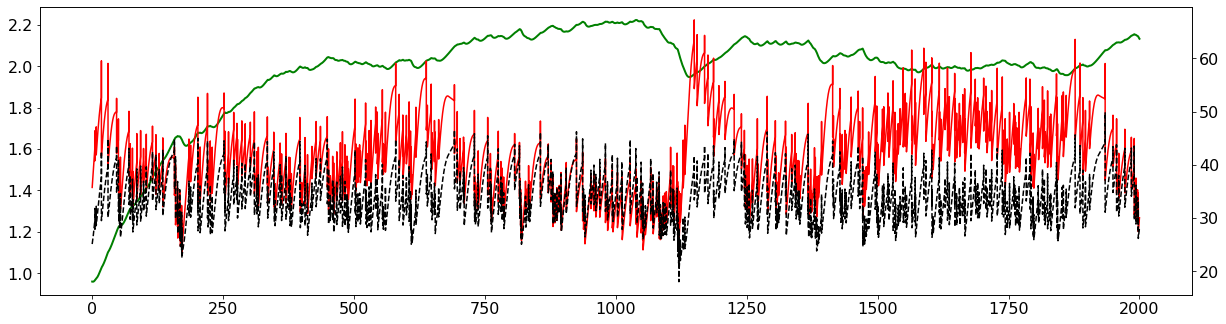

In [20]:
fig = plt.figure()
fig.set_figwidth(16)
fig.set_figheight(4)
ax1 = fig.add_axes([0,0,1,1])
ax1.plot(time[0:20000000], Bh[200000:20200000], color="green", linewidth=2)
#ax1.set_ylabel(r'$B_H$ [gCm$^{-3}$]', fontsize=16)
#plt.legend(fontsize=16)
ax2=ax1.twinx()
ax2.plot(time[0:20000000], H[200000:20200000], color = "red")
ax2.plot(time[0:20000000], c[200000:20200000], color = "k",linestyle="dashed")
#ax2.set_ylabel(r'$\bar H$ [ppb]', fontsize=16)
#ax2.set_ylim([25,100])
#plt.legend(fontsize=16)
plt.show();

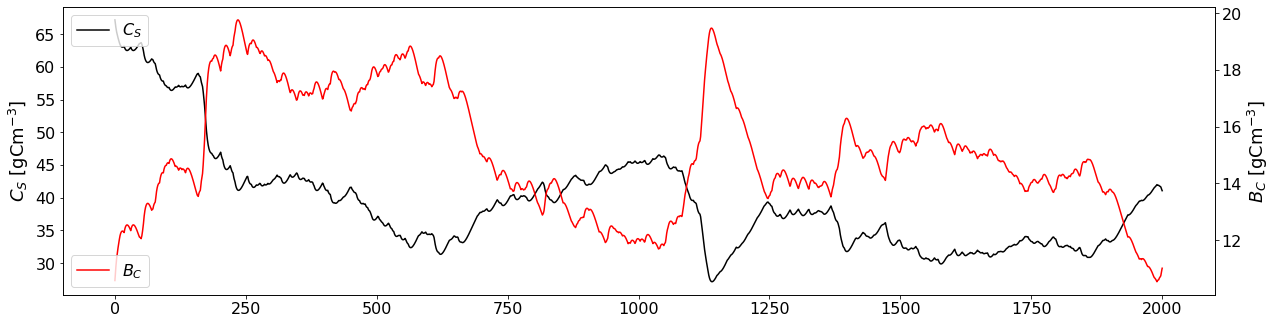

In [16]:
fig = plt.figure()
fig.set_figwidth(16)
fig.set_figheight(4)
ax1 = fig.add_axes([0,0,1,1])
ax1.plot(time[0:20000000], Cs[200000:20200000], color="black", label=r'$C_S$')
plt.legend(loc="upper left",fontsize=16)
ax1.set_ylabel(r'$C_S$ [gCm$^{-3}$]', fontsize=18)
ax2=ax1.twinx()
ax2.plot(time[0:20000000], Bc[200000:20200000], color = "red", label=r'$B_C$')
ax2.set_ylabel(r'$B_C$ [gCm$^{-3}$]', fontsize=18)
plt.legend(loc="lower left",fontsize=16)
plt.show();

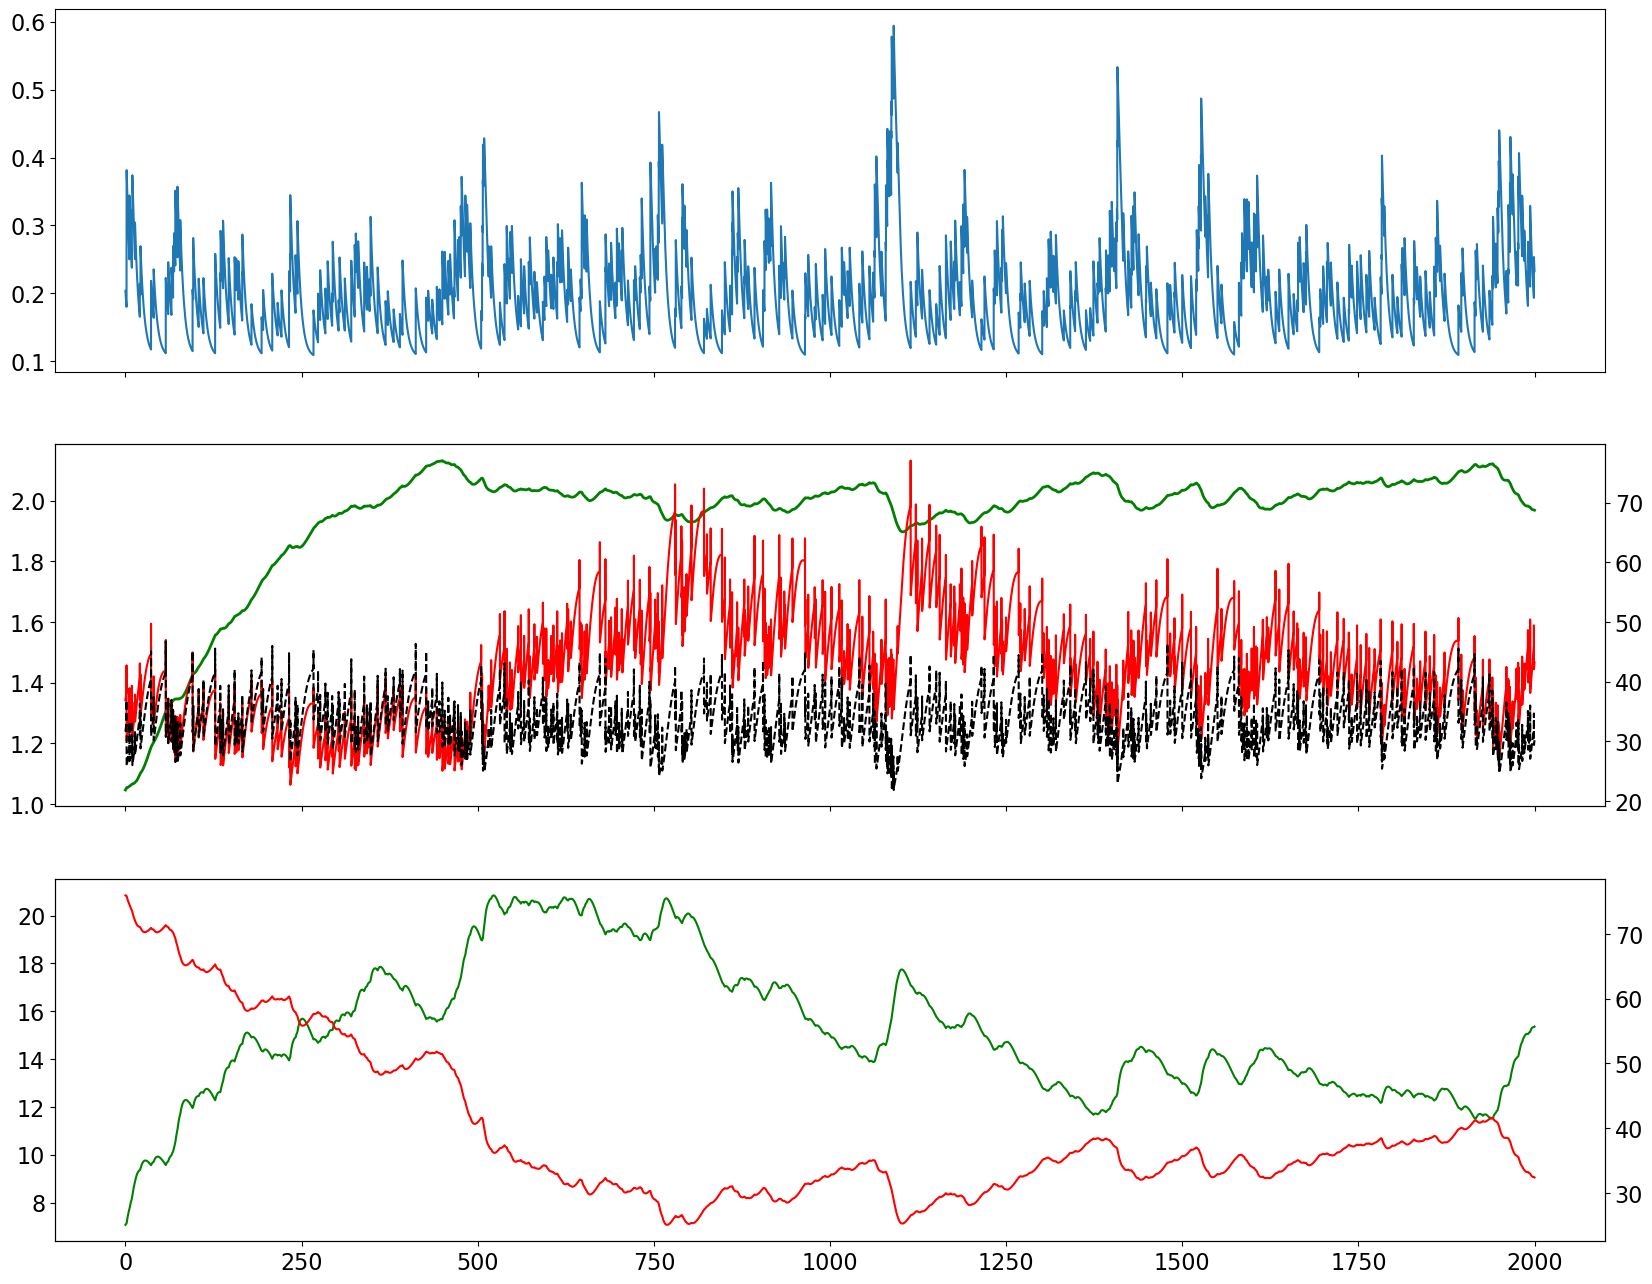

In [7]:

fig, axs = plt.subplots(3, 1, figsize=(20,16), sharex=True)
axs[0].plot(time[0:2000000], ss11[20000:2020000])
axs[1].plot(time[0:2000000], Bh11[20000:2020000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:2000000], H11[20000:2020000], color="red")
ax2.plot(time[0:2000000], c11[20000:2020000], color="black", linestyle="dashed")
axs[2].plot(time[0:2000000], Bc11[20000:2020000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:2000000], Cs11[20000:2020000], color="red")

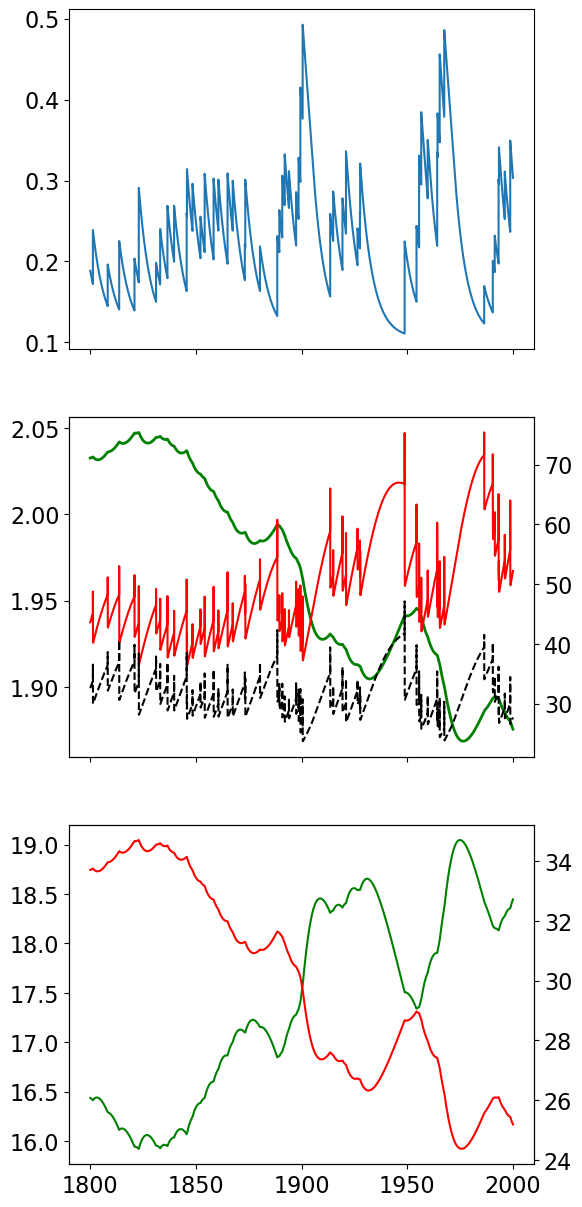

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(6,15), sharex=True)
axs[0].plot(time[1800000:2000000], ss11[1800000:2000000])
axs[1].plot(time[1800000:2000000], Bh11[1800000:2000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[1800000:2000000], H11[1800000:2000000], color="red")
ax2.plot(time[1800000:2000000], c11[1800000:2000000], color="black", linestyle="dashed")
axs[2].plot(time[1800000:2000000], Bc11[1800000:2000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[1800000:2000000], Cs11[1800000:2000000], color="red")

In [20]:
# Deposition veocity
Vd = np.zeros(len(time))
Vd_m = np.zeros(len(time))
for i in range(int(length/dt)):
    Vd[i] = (gt(ss[i])*vbd(ss[i], Cs[i], Bh[i]))/(gt(ss[i])+vbd(ss[i], Cs[i], Bh[i]))
    #Vd_m[i] = (gt(ss[i])*(0.03*fh(ss[i])*hh*Zr))/(gt(ss[i])+(0.03*fh(ss[i])*hh*Zr))
    #m = (gt(ss[i])*(0.03*fh(ss[i])*hh*Zr))/(gt(ss[i])+(0.03*fh(ss[i])*hh*Zr))
    #Vd.append(d)
    #Vd_m.append(m)
    


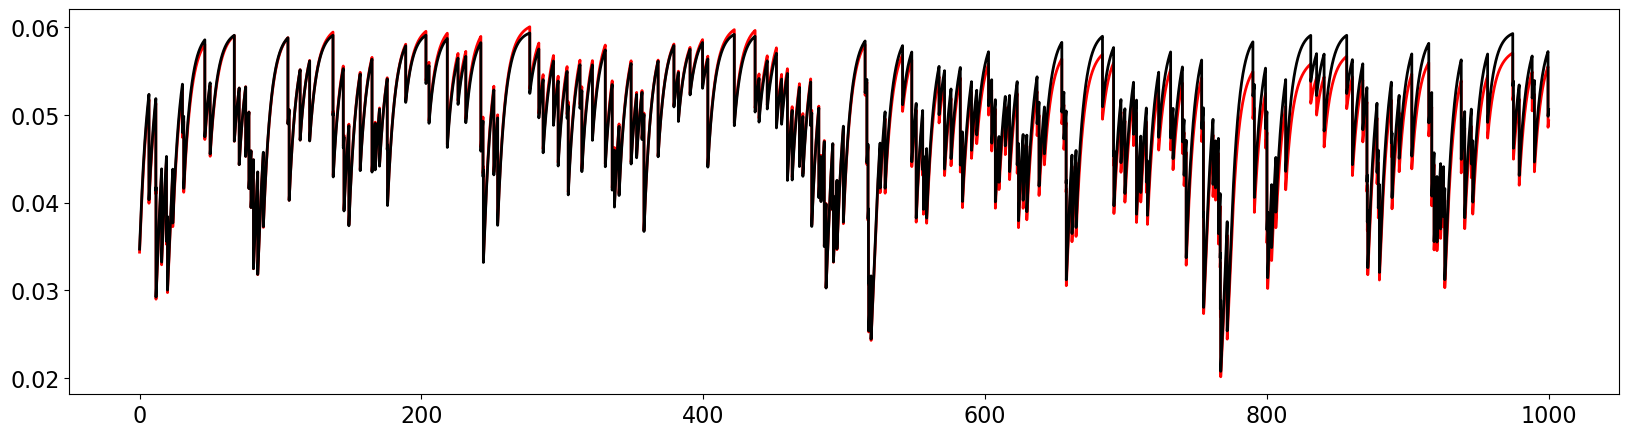

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(20,5), sharex=True)
#axs[0].plot(time[0:1000000], ss[10000:1010000])
axs.plot(time[0:1000000], Vd11[10000:1010000], color="red", linewidth=2)
axs.plot(time[0:1000000], Vd_m11[10000:1010000], color="black", linewidth=2);